<a href="https://colab.research.google.com/github/PreetiYadav99/Machine-Learning-Project/blob/main/Email_Spam_Detection_with_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import pandas for data loading and data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import regular expressions for text cleaning
import re

# Import string module for punctuation handling
import string

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import TF-IDF Vectorizer to convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Multinomial Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Import NLTK
import nltk

# Import English stopwords
from nltk.corpus import stopwords

# Download stopwords if they are not already available
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Download the SMS Spam Collection dataset from UCI
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

# Extract the downloaded ZIP file
!unzip -o smsspamcollection.zip

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [4]:
# Download the SMS Spam Collection dataset from UCI
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

# Extract the downloaded ZIP file
!unzip -o smsspamcollection.zip

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [6]:
# Load the dataset using pandas
# sep='\t' because the dataset contains tab-separated values
# header=None because the original file does not contain column names
df = pd.read_csv(
    'SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

# Display the first five rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display information about columns and data types
df.info()

Dataset Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
# Check the number of missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label      0
message    0
dtype: int64


In [9]:
# Count duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Display the new shape after removing duplicates
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 403
Shape after removing duplicates: (5169, 2)


In [11]:
# Count the number of messages in each class
class_counts = df['label'].value_counts()

print("Class Counts:")
print(class_counts)

Class Counts:
label
ham     4516
spam     653
Name: count, dtype: int64


In [12]:
# Calculate the percentage of each class
class_percentage = df['label'].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentage)

Class Percentage:
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


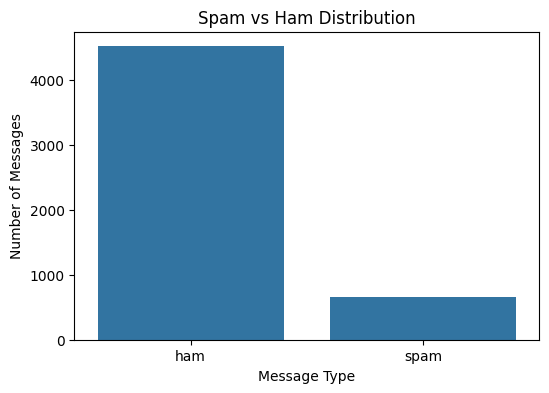

In [13]:
# Create a bar chart showing the distribution of ham and spam messages
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='label')

# Add chart title
plt.title('Spam vs Ham Distribution')

# Add x-axis label
plt.xlabel('Message Type')

# Add y-axis label
plt.ylabel('Number of Messages')

# Display the chart
plt.show()

In [14]:
# Convert text labels into numerical values
# ham = 0
# spam = 1

df['label_encoded'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Display the updated dataset
df.head()

,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
# Get the list of English stopwords from NLTK
stop_words = set(stopwords.words('english'))


# Create a function for text preprocessing
def preprocess_text(text):

    # Convert all characters to lowercase
    text = text.lower()

    # Remove punctuation marks
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers using regular expression
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split the sentence into individual words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join the remaining words back into a sentence
    return ' '.join(words)

In [16]:
# Apply the preprocessing function to every message
df['clean_message'] = df['message'].apply(preprocess_text)

# Display original and cleaned messages
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


In [17]:
# X contains the input text messages
X = df['clean_message']

# y contains the target labels
# 0 = ham
# 1 = spam
y = df['label_encoded']

# Display the first few values
print(X.head())
print(y.head())

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: clean_message, dtype: object
0    0
1    0
2    1
3    0
4    0
Name: label_encoded, dtype: int64


In [18]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the number of samples
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4135
Testing Samples: 1034


In [19]:
# Create the TF-IDF vectorizer
# max_features limits the vocabulary to the most useful 5000 features
# ngram_range=(1,2) considers both single words and pairs of words
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Learn the vocabulary and transform the training messages
# fit_transform() should only be applied to training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the testing messages using the vocabulary learned from training data
X_test_tfidf = tfidf.transform(X_test)

# Display the dimensions of the generated TF-IDF matrices
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4135, 5000)
Testing TF-IDF Shape: (1034, 5000)


In [20]:
# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model using training data
nb_model.fit(X_train_tfidf, y_train)

# Predict the classes for test messages
nb_pred = nb_model.predict(X_test_tfidf)

In [21]:
# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

# Calculate precision
nb_precision = precision_score(y_test, nb_pred)

# Calculate recall
nb_recall = recall_score(y_test, nb_pred)

# Calculate F1-score
nb_f1 = f1_score(y_test, nb_pred)


# Display the results
print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9661508704061895
Precision: 1.0
Recall   : 0.732824427480916
F1 Score : 0.8458149779735683


In [22]:
# Display precision, recall and F1-score for both classes
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.73      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



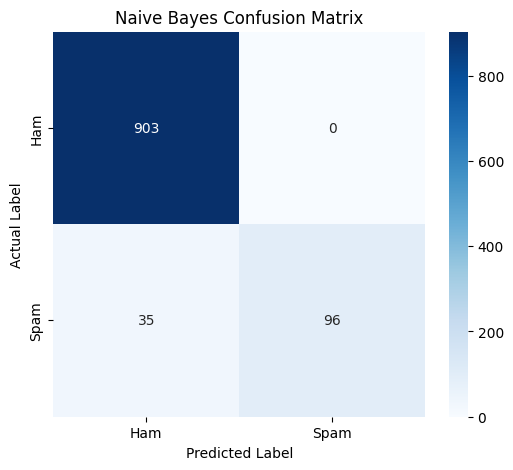

In [23]:
# Calculate the confusion matrix
cm_nb = confusion_matrix(y_test, nb_pred)

# Create the heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

# Add labels
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Add title
plt.title('Naive Bayes Confusion Matrix')

# Display the plot
plt.show()

In [24]:
# Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model using the TF-IDF training data
lr_model.fit(X_train_tfidf, y_train)

# Predict the classes for test messages
lr_pred = lr_model.predict(X_test_tfidf)

In [25]:
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

# Calculate precision
lr_precision = precision_score(y_test, lr_pred)

# Calculate recall
lr_recall = recall_score(y_test, lr_pred)

# Calculate F1-score
lr_f1 = f1_score(y_test, lr_pred)


# Display the results
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9535783365570599
Precision: 0.9560439560439561
Recall   : 0.6641221374045801
F1 Score : 0.7837837837837838


In [26]:
# Display detailed classification metrics
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.96      0.66      0.78       131

    accuracy                           0.95      1034
   macro avg       0.95      0.83      0.88      1034
weighted avg       0.95      0.95      0.95      1034



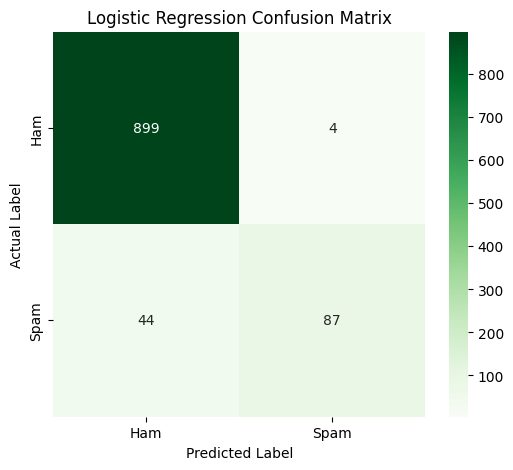

In [27]:
# Calculate confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)

# Create a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

# Add axis labels
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Add title
plt.title('Logistic Regression Confusion Matrix')

# Display the plot
plt.show()

In [28]:
# Create a DataFrame containing the performance of both models
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression'
    ],

    'Accuracy': [
        nb_accuracy,
        lr_accuracy
    ],

    'Precision': [
        nb_precision,
        lr_precision
    ],

    'Recall': [
        nb_recall,
        lr_recall
    ],

    'F1 Score': [
        nb_f1,
        lr_f1
    ]
})

# Display model comparison
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.966151,1.000000,0.732824,0.845815
1,Logistic Regression,0.953578,0.956044,0.664122,0.783784


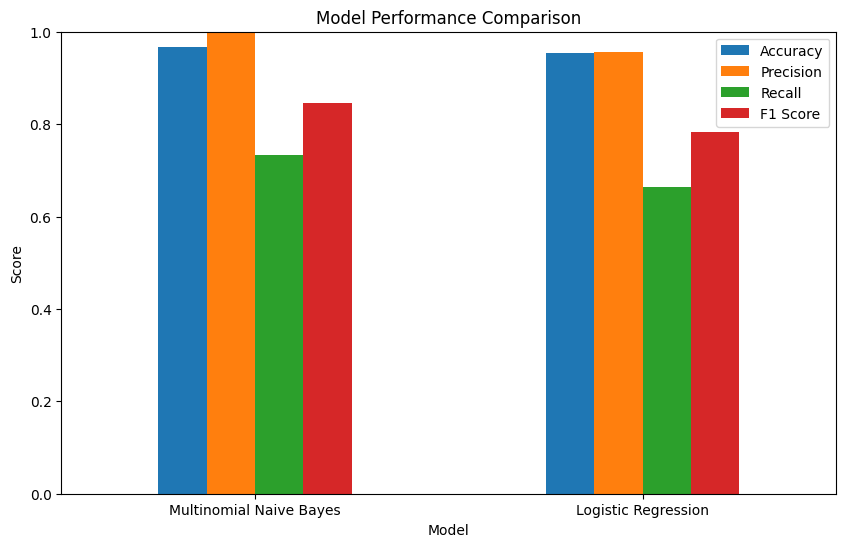

In [29]:
# Set Model column as the index
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

# Add title
plt.title('Model Performance Comparison')

# Add y-axis label
plt.ylabel('Score')

# Set y-axis range from 0 to 1
plt.ylim(0, 1)

# Keep model names horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [30]:
# Install the WordCloud library
!pip install wordcloud -q

In [31]:
# Import WordCloud for visualizing frequently occurring words
from wordcloud import WordCloud

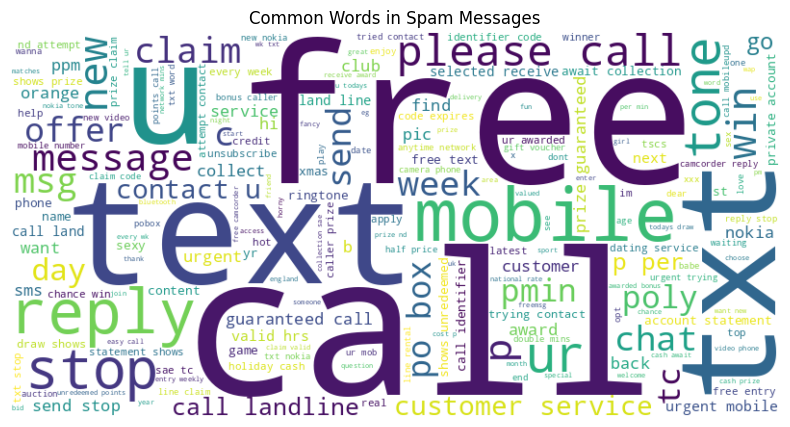

In [32]:
# Combine all cleaned spam messages into one large string
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

# Generate the word cloud
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

# Display the word cloud
plt.figure(figsize=(10, 5))

plt.imshow(
    spam_wordcloud,
    interpolation='bilinear'
)

# Remove axis markings
plt.axis('off')

# Add title
plt.title('Common Words in Spam Messages')

# Display the plot
plt.show()

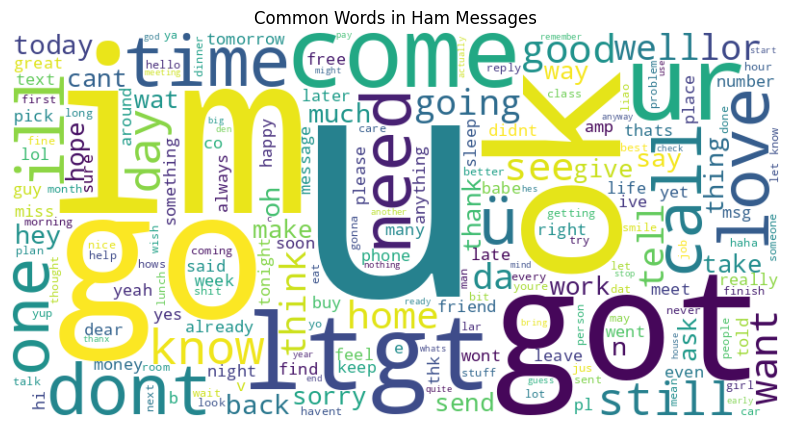

In [33]:
# Combine all cleaned ham messages into one large string
ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)

# Generate the word cloud
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_text)

# Display the word cloud
plt.figure(figsize=(10, 5))

plt.imshow(
    ham_wordcloud,
    interpolation='bilinear'
)

# Remove axis markings
plt.axis('off')

# Add title
plt.title('Common Words in Ham Messages')

# Display the plot
plt.show()

In [34]:
# Create a function to predict whether a new message is spam or ham
def predict_message(message):

    # Apply the same preprocessing used during model training
    cleaned_message = preprocess_text(message)

    # Convert the cleaned message into TF-IDF features
    message_vector = tfidf.transform([cleaned_message])

    # Use Logistic Regression to make the prediction
    prediction = lr_model.predict(message_vector)[0]

    # Convert numerical prediction into human-readable output
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [36]:
# Test with a spam-like message
message1 = "Congratulations! You won a free lottery prize. Claim now!"

# Test with a normal message
message2 = "Hey, are we meeting today at 5 PM?"

# Display predictions
print("Message 1:", predict_message(message1))
print("Message 2:", predict_message(message2))

Message 1: SPAM
Message 2: HAM
